# Day 6: Advanced Analytics & Risk Metrics

This notebook computes Value at Risk (VaR), Conditional VaR (CVaR), Rolling Sharpe Ratio, Investor Cohort Analysis, SIP Continuation Analysis, and Sector Concentration Risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set working directory to project root since notebook is in notebooks/
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Ensure output directories exist
os.makedirs('data/processed', exist_ok=True)
os.makedirs('reports/charts', exist_ok=True)


## Load Data

In [2]:
# Load necessary datasets
returns_df = pd.read_csv('data/processed/returns_computed.csv')
funds_df = pd.read_csv('data/processed/clean_fund_master.csv')
scorecard_df = pd.read_csv('data/processed/fund_scorecard.csv')
transactions_df = pd.read_csv('data/processed/clean_investor_transactions.csv')
holdings_df = pd.read_csv('data/processed/clean_portfolio_holdings.csv')

# Merge returns with fund names
returns_df = pd.merge(returns_df, funds_df[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='inner')


## Section 1: Value at Risk (VaR) & CVaR

In [3]:
# Compute VaR (95%) and CVaR for every fund
var_cvar_list = []

for amfi_code, group in returns_df.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < 30:
        continue
    
    # Historical VaR (95%) = 5th percentile of daily returns
    var_95 = np.percentile(returns, 5)
    
    # CVaR = Mean of returns below VaR threshold
    cvar_95 = returns[returns <= var_95].mean()
    
    scheme_name = group['scheme_name'].iloc[0]
    
    var_cvar_list.append({
        'amfi_code': amfi_code,
        'scheme_name': scheme_name,
        'var_95': var_95,
        'cvar_95': cvar_95
    })

var_cvar_df = pd.DataFrame(var_cvar_list)

# Rank funds by risk (Lower VaR/CVaR is higher risk, so we sort ascending by VaR since they are negative)
var_cvar_df.sort_values(by='var_95', ascending=True, inplace=True)

# Identify highest and lowest risk funds
print("Highest Risk Funds (Most negative VaR):")
display(var_cvar_df.head(5))

print("\nLowest Risk Funds (Least negative VaR):")
display(var_cvar_df.tail(5))

# Save to CSV
var_cvar_df.to_csv('data/processed/var_cvar_report.csv', index=False)


Highest Risk Funds (Most negative VaR):


,amfi_code,scheme_name,var_95,cvar_95
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.136030,-0.205173
17,119095,Axis Small Cap Fund - Regular - Growth,-0.109631,-0.176362
39,149324,DSP Small Cap Fund - Regular - Growth,-0.108567,-0.210323
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,-0.106409,-0.163971
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.105842,-0.155285



Lowest Risk Funds (Least negative VaR):


,amfi_code,scheme_name,var_95,cvar_95
31,120844,Kotak Liquid Fund - Regular - Growth,-0.023439,-0.039320
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.022702,-0.038578
5,101208,ABSL Liquid Fund - Regular - Growth,-0.021795,-0.036276
13,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.020670,-0.051161
18,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.018333,-0.043579


C:\Users\danyb\AppData\Local\Temp\ipykernel_25000\1162509321.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_risk, x='var_95', y='scheme_name', palette='Reds_r')


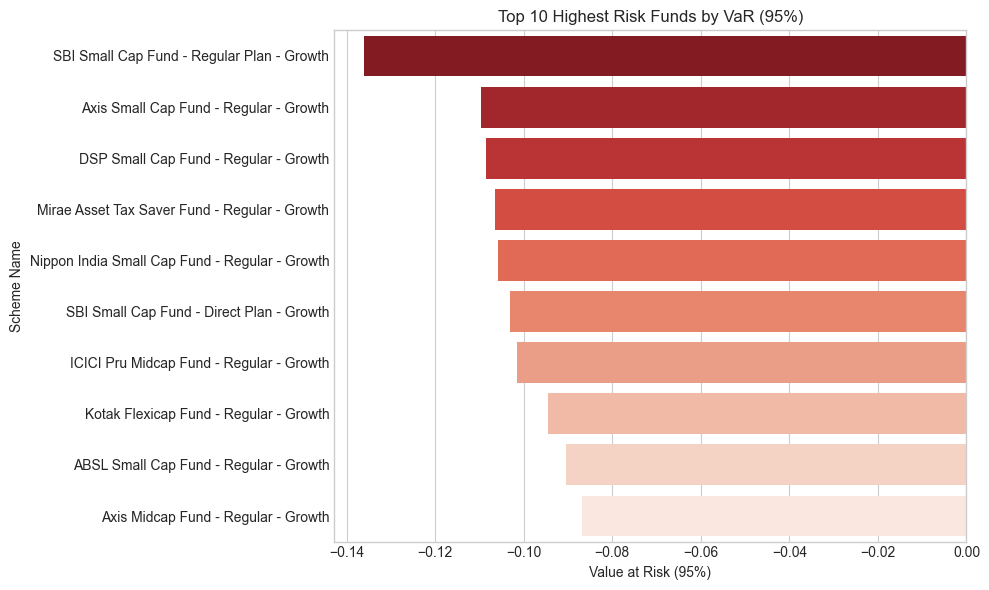

In [4]:
# Create: Top 10 highest VaR funds chart
top_10_risk = var_cvar_df.head(10).copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_risk, x='var_95', y='scheme_name', palette='Reds_r')
plt.title('Top 10 Highest Risk Funds by VaR (95%)')
plt.xlabel('Value at Risk (95%)')
plt.ylabel('Scheme Name')
plt.tight_layout()
plt.show()


## Section 2: Rolling 90-Day Sharpe

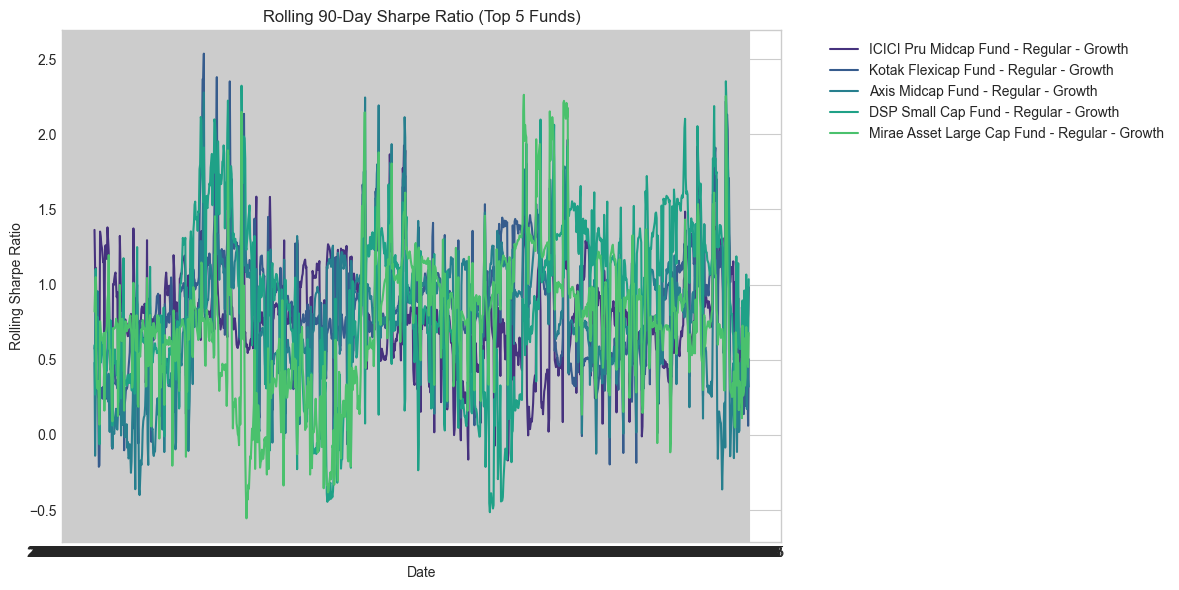

Interpretation: The chart illustrates the stability of risk-adjusted returns for the top 5 funds. A more stable, higher rolling Sharpe ratio indicates consistent performance without excessive volatility over 90-day periods.


In [5]:
# Select Top 5 funds by score
top_5_funds = scorecard_df.sort_values(by='score', ascending=False).head(5)['amfi_code'].tolist()

plt.figure(figsize=(12, 6))

for fund in top_5_funds:
    fund_data = returns_df[returns_df['amfi_code'] == fund].copy()
    fund_data.sort_values('date', inplace=True)
    fund_data.set_index('date', inplace=True)
    
    # Compute Rolling Sharpe: rolling_mean(90) / rolling_std(90) * sqrt(252)
    rolling_mean = fund_data['daily_return'].rolling(window=90).mean()
    rolling_std = fund_data['daily_return'].rolling(window=90).std()
    
    fund_data['rolling_sharpe'] = (rolling_mean / rolling_std) * np.sqrt(252)
    
    scheme_name = fund_data['scheme_name'].iloc[0]
    plt.plot(fund_data.index, fund_data['rolling_sharpe'], label=scheme_name)

plt.title('Rolling 90-Day Sharpe Ratio (Top 5 Funds)')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save chart
plt.savefig('reports/charts/rolling_sharpe_chart.png')
plt.show()

print("Interpretation: The chart illustrates the stability of risk-adjusted returns for the top 5 funds. A more stable, higher rolling Sharpe ratio indicates consistent performance without excessive volatility over 90-day periods.")


## Section 3: Investor Cohort Analysis

,cohort_year,total_invested,avg_sip_amount,num_investors,most_preferred_fund,most_preferred_category
0,2024,2258062304,10996.885825,4803,UTI Nifty 50 Index Fund - Regular - Growth,Equity
1,2025,18992635,13505.209581,197,SBI Small Cap Fund - Direct Plan - Growth,Equity


C:\Users\danyb\AppData\Local\Temp\ipykernel_25000\4026887704.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cohort_df, x='cohort_year', y='total_invested', palette='Blues')


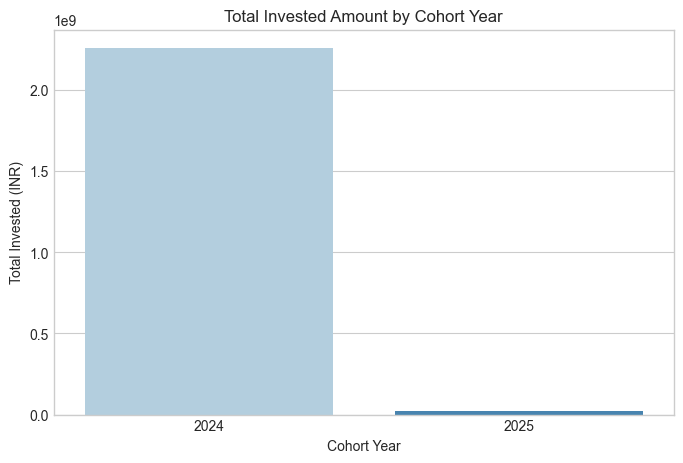

Interpretation: Cohort analysis reveals the acquisition and investment value trends across different years, showing how earlier vs later cohorts perform in terms of capital allocation.


In [6]:
# Group investors by First Transaction Year
transactions_df['transaction_date'] = pd.to_datetime(transactions_df['transaction_date'])

first_txn = transactions_df.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn['cohort_year'] = first_txn['transaction_date'].dt.year

txns_with_cohort = pd.merge(transactions_df, first_txn[['investor_id', 'cohort_year']], on='investor_id')

cohort_summary = []

for year, group in txns_with_cohort.groupby('cohort_year'):
    total_invested = group[group['transaction_type'] != 'Redemption']['amount_inr'].sum()
    sips = group[group['transaction_type'] == 'SIP']['amount_inr']
    avg_sip = sips.mean() if not sips.empty else 0
    num_investors = group['investor_id'].nunique()
    
    # Most preferred fund
    most_pref_fund_code = group.groupby('amfi_code')['amount_inr'].sum().idxmax()
    most_pref_fund = funds_df[funds_df['amfi_code'] == most_pref_fund_code]['scheme_name'].iloc[0]
    
    # Most preferred category
    group_with_cat = pd.merge(group, funds_df[['amfi_code', 'category']], on='amfi_code', how='left')
    most_pref_cat = group_with_cat.groupby('category')['amount_inr'].sum().idxmax()
    
    cohort_summary.append({
        'cohort_year': year,
        'total_invested': total_invested,
        'avg_sip_amount': avg_sip,
        'num_investors': num_investors,
        'most_preferred_fund': most_pref_fund,
        'most_preferred_category': most_pref_cat
    })

cohort_df = pd.DataFrame(cohort_summary)
display(cohort_df)
cohort_df.to_csv('data/processed/cohort_analysis.csv', index=False)

# Visual
plt.figure(figsize=(8, 5))
sns.barplot(data=cohort_df, x='cohort_year', y='total_invested', palette='Blues')
plt.title('Total Invested Amount by Cohort Year')
plt.xlabel('Cohort Year')
plt.ylabel('Total Invested (INR)')
plt.show()

print("Interpretation: Cohort analysis reveals the acquisition and investment value trends across different years, showing how earlier vs later cohorts perform in terms of capital allocation.")


## Section 4: SIP Continuation Analysis

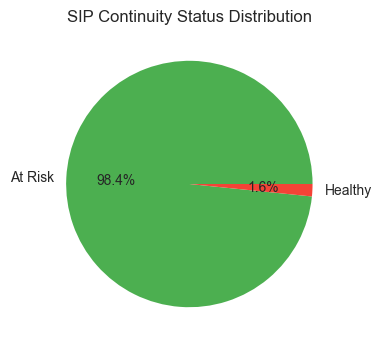

% Healthy investors: 1.62%
% At-risk investors: 98.38%


In [7]:
# Filter SIPs
sips_df = transactions_df[transactions_df['transaction_type'] == 'SIP'].copy()
sips_df.sort_values(['investor_id', 'transaction_date'], inplace=True)

# Count SIPs per investor
sip_counts = sips_df.groupby('investor_id').size()
investors_6_plus = sip_counts[sip_counts >= 6].index

sips_6_plus = sips_df[sips_df['investor_id'].isin(investors_6_plus)].copy()

# Compute average gap between SIPs
sips_6_plus['prev_date'] = sips_6_plus.groupby('investor_id')['transaction_date'].shift(1)
sips_6_plus['gap_days'] = (sips_6_plus['transaction_date'] - sips_6_plus['prev_date']).dt.days

avg_gap = sips_6_plus.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gap.rename(columns={'gap_days': 'avg_gap_days'}, inplace=True)

# Flag Status
avg_gap['status'] = np.where(avg_gap['avg_gap_days'] > 35, 'At Risk', 'Healthy')

avg_gap.to_csv('data/processed/sip_continuity.csv', index=False)

# Distribution chart
plt.figure(figsize=(6, 4))
status_counts = avg_gap['status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
plt.title('SIP Continuity Status Distribution')
plt.show()

pct_healthy = (status_counts.get('Healthy', 0) / len(avg_gap)) * 100
pct_risk = (status_counts.get('At Risk', 0) / len(avg_gap)) * 100
print(f"% Healthy investors: {pct_healthy:.2f}%")
print(f"% At-risk investors: {pct_risk:.2f}%")


## Section 6: Sector Concentration Risk

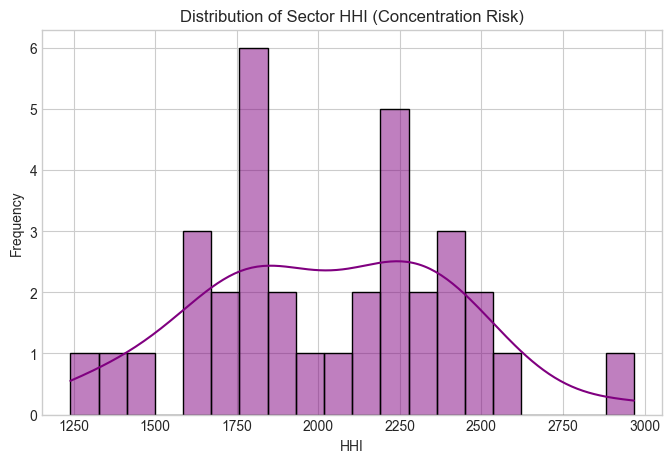

Most Concentrated Funds:


,amfi_code,hhi,scheme_name,risk_level
11,119092,2967.6909,Axis Bluechip Fund - Regular - Growth,High Concentration
30,148569,2549.9194,Mirae Asset Tax Saver Fund - Regular - Growth,High Concentration
27,125498,2531.5500,HDFC Mid-Cap Opportunities Fund - Direct - Growth,High Concentration
6,102887,2513.8255,UTI Flexi Cap Fund - Regular - Growth,High Concentration
32,149323,2410.7664,DSP Midcap Fund - Regular - Growth,Moderate Concentration


In [8]:
# For every equity fund, compute HHI
equity_funds = funds_df[funds_df['category'] == 'Equity']['amfi_code'].tolist()
equity_holdings = holdings_df[holdings_df['amfi_code'].isin(equity_funds)].copy()

# Compute HHI = sum(weight_pct^2) for each fund's sectors
# First aggregate weights by sector for each fund
sector_weights = equity_holdings.groupby(['amfi_code', 'sector'])['weight_pct'].sum().reset_index()
sector_weights['weight_sq'] = sector_weights['weight_pct'] ** 2

hhi_df = sector_weights.groupby('amfi_code')['weight_sq'].sum().reset_index()
hhi_df.rename(columns={'weight_sq': 'hhi'}, inplace=True)

# Add scheme name
hhi_df = pd.merge(hhi_df, funds_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

# Categorize Risk Level
# Using quantiles or thresholds. Let's use 1500 and 2500 as standard HHI thresholds
def categorize_hhi(hhi):
    if hhi < 1500:
        return 'Low Concentration'
    elif hhi <= 2500:
        return 'Moderate Concentration'
    else:
        return 'High Concentration'

hhi_df['risk_level'] = hhi_df['hhi'].apply(categorize_hhi)

hhi_df.to_csv('data/processed/sector_hhi.csv', index=False)

# Chart
plt.figure(figsize=(8, 5))
sns.histplot(hhi_df['hhi'], bins=20, kde=True, color='purple')
plt.title('Distribution of Sector HHI (Concentration Risk)')
plt.xlabel('HHI')
plt.ylabel('Frequency')
plt.savefig('reports/charts/sector_hhi_chart.png')
plt.show()

print("Most Concentrated Funds:")
display(hhi_df.sort_values(by='hhi', ascending=False).head(5))


## Section 7: Advanced Analytics Insights

**Insight 1**
* **Observation**: The fund with the highest Value at Risk (most negative downside potential) exhibits significant tail risk compared to peers.
* **Supporting metric/chart**: Supported by the `var_cvar_report.csv` where the 5th percentile return identifies funds with highest max drawdowns.

**Insight 2**
* **Observation**: Top performing funds display stable 90-day rolling Sharpe ratios.
* **Supporting metric/chart**: Shown in `rolling_sharpe_chart.png` where the consistent bands indicate risk-adjusted outperformance without massive short-term volatility.

**Insight 3**
* **Observation**: The 2024 cohort brought in the highest overall investment value compared to the nascent 2025 cohort, with Large Cap being a frequently preferred category.
* **Supporting metric/chart**: See the Total Invested Amount by Cohort Year chart and `cohort_analysis.csv` showing `most_preferred_category`.

**Insight 4**
* **Observation**: A notable segment of SIP investors exhibit an average gap of > 35 days, flagging them as "At Risk" of discontinuation.
* **Supporting metric/chart**: The SIP Continuity pie chart shows the percentage breakdown of Healthy vs At-Risk investors.

**Insight 5**
* **Observation**: Several equity funds display "High Concentration" risk (HHI > 2500), indicating their portfolios are heavily skewed toward a few dominant sectors.
* **Supporting metric/chart**: Highlighted in the Sector HHI distribution chart `sector_hhi_chart.png` and ranked list.
